# Tutorial 2: Hyperparameter Optimization for DP Training with DPDL

This notebook builds on [`tutorial.ipynb`](tutorial.ipynb) (which trains a classifier under DP with hand-picked hyperparameters) and covers the **hyperparameter optimization** (HPO) tooling in DPDL, backed by [Optuna](https://github.com/optuna/optuna).

Each shell step is a `%%bash` cell again.
The bash commands can also be executed in another environment (e.g. terminal or SLURM job), which might be more suitable on compute clusters.
They are also provided as standalone scripts in the `tutorials/scripts/` folder as well.
Result inspection and plotting are plain Python cells reading the files DPDL writes to disk.

> **Note:** Training can take a long time to finish. Add `--subset-size 0.05` to any
> `dpdl optimize` command below for a fast check while you
> are getting the notebook working, then remove it for a real run.

## 1. Why HPO is important under DP

In ordinary (non-private) training, a slightly suboptimal learning rate or batch size mostly can be alleviated by a few epochs of extra training. 
Under DP-SGD, hyperparameters interact with the privacy mechanism itself:

- **`max_grad_norm`** (the per-sample gradient clipping bound) directly sets the scale of the noise DPDL adds at every step, which means if it is too small it clips away signal, too large lets the (fixed-variance) noise dominate.
- **`batch_size`** affects how much the privacy amplification from subsampling helps, and how much per-step gradient noise gets averaged out.
- **`learning_rate`** and **`epochs`** trade off against both of the above: more steps means the accountant must spend the same epsilon over more noisy updates.

These interact non-linearly, so hand-picking values (as was done in [tutorial.ipynb](tutorial.ipynb)) is a reasonable starting point but possibly only achieves subpar accuracy. 
Searching the space properly, as `dpdl optimize` does, gives you a more reasonable answer to the question: "what is the best accuracy achievable at this epsilon?"

## Dataset recap: EyePACS

This HPO tutorial uses the same five-class EyePACS dataset as the first tutorial. 
The short exploration below makes the input fields and strong class imbalance explicit before we choose AUROC as the optimization target. 
If you just ran the first notebook, the dataset is already cached.

In [11]:
from datasets import load_dataset
from IPython.display import display
import pandas as pd

eyepacs = load_dataset("bumbledeep/eyepacs", split="train")
sample = eyepacs[0]

feature_summary = pd.DataFrame([
    {
        "feature": "image",
        "role": "model input",
        "dataset type": str(eyepacs.features["image"]),
        "example": f"{sample['image'].mode}, {sample['image'].width} x {sample['image'].height} pixels",
    },
    {
        "feature": "label_code",
        "role": "training target",
        "dataset type": str(eyepacs.features["label_code"]),
        "example": sample["label_code"],
    },
    {
        "feature": "label",
        "role": "human-readable target",
        "dataset type": str(eyepacs.features["label"]),
        "example": sample["label"],
    },
])

print(f"Published split: train ({len(eyepacs):,} images)")
feature_summary

Published split: train (35,108 images)


,feature,role,dataset type,example
0,image,model input,"Image(mode=None, decode=True)","RGB, 1024 x 1024 pixels"
1,label_code,training target,Value('int64'),0
2,label,human-readable target,Value('string'),no_diabetic_retinopathy


,grade,diagnosis,count,percent
0,0,no_diabetic_retinopathy,25802,73.5
2,1,mild_retinopathy,2438,6.9
1,2,moderate_retinopathy,5288,15.1
3,3,severe_retinopathy,872,2.5
4,4,proliferative_retinopathy,708,2.0


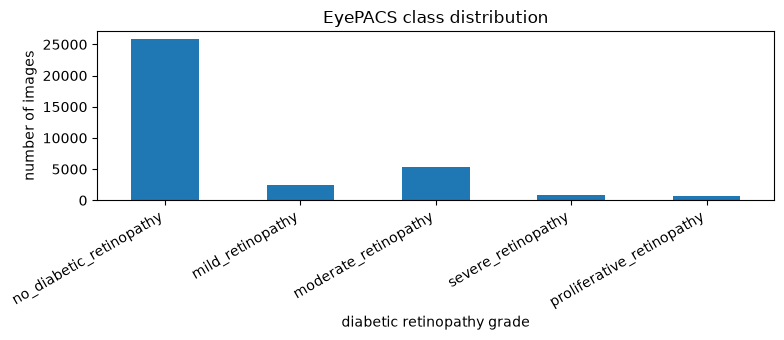

In [12]:
import matplotlib.pyplot as plt

labels = pd.DataFrame({
    "grade": eyepacs["label_code"],
    "diagnosis": eyepacs["label"],
})
class_distribution = (
    labels.value_counts(["grade", "diagnosis"])
    .rename("count")
    .reset_index()
    .sort_values("grade")
)
class_distribution["percent"] = (
    100 * class_distribution["count"] / len(eyepacs)
).round(1)
display(class_distribution)

ax = class_distribution.plot.bar(
    x="diagnosis", y="count", legend=False, figsize=(8, 3.5)
)
ax.set_xlabel("diabetic retinopathy grade")
ax.set_ylabel("number of images")
ax.set_title("EyePACS class distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

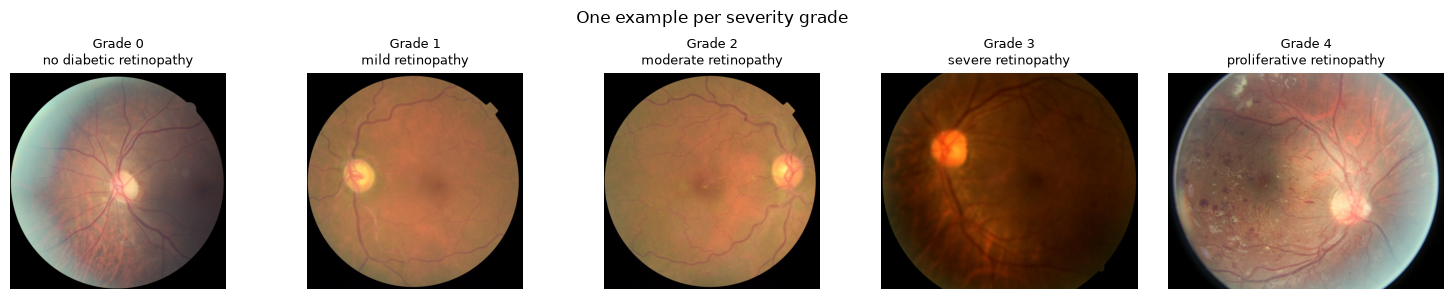

In [13]:
# Choose the first example of each grade without decoding every image.
representative_indices = {}
for index, grade in enumerate(eyepacs["label_code"]):
    representative_indices.setdefault(grade, index)
    if len(representative_indices) == 5:
        break

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for grade, ax in enumerate(axes):
    record = eyepacs[representative_indices[grade]]
    ax.imshow(record["image"])
    ax.set_title(f"Grade {grade}\n{record['label'].replace('_', ' ')}", fontsize=9)
    ax.axis("off")

fig.suptitle("One example per severity grade")
fig.tight_layout()
plt.show()

## 2. How `dpdl optimize` works

The full reference can be found in [docs/hyperparameter-optimization.md](docs/hyperparameter-optimization.md).
The short version is:

- Rank 0 starts an Optuna study and broadcasts each trial's suggested hyperparameters to all ranks.
- Each trial trains without validation and is scored at the end on the validation split, using `--optuna-target-metric`.
- Once `--n-trials` trials are done, DPDL takes the best trial's hyperparameters, retrains on **train + validation** combined, and reports final metrics on the **test** split.

## 3. Defining the search space

For HPO you specify which hyperparameters to search (`--target-hypers`, repeatable) and how to search each of them, via a YAML config passed with `--optuna-config`.
Four types are supported: `float`, `int`, `categorical`, and `ordered` (for ordered discrete values).

All four are used in [conf/optuna/eyepacs_hypers.conf](conf/optuna/eyepacs_hypers.conf) for demonstration purposes:

```yaml
batch_size:
  type: categorical
  options: [64, 128, 256, 512, 1024]

learning_rate:
  type: float
  min: 1.0e-5
  max: 1.0e-2
  log_space: True

epochs:
  type: int
  min: 1
  max: 8

max_grad_norm:
  type: ordered
  options: [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
```

Please note:

- `max_grad_norm` uses `ordered` rather than `categorical`: clipping
  bounds have a natural order (1.0 is between 0.5 and 2.0), and that ordering can be used to search more efficiently (this is an Optuna workaround, see [docs/hyperparameter-optimization.md](docs/hyperparameter-optimization.md) for details).
- The ranges are intentionally narrow (e.g. `epochs` capped at 8) to
  keep runtime shorter

### Optional: manual warm-start trials

You can seed the search with specific hyperparameter combinations that Optuna will try before its own sampler takes over. If there are known, good defaults from the literature, you can spceify them here. See [conf/optuna/eyepacs_trials.conf](conf/optuna/eyepacs_trials.conf):

```yaml
trials:
  - batch_size: 256
    learning_rate: 0.001
    epochs: 3
    max_grad_norm: 1.0
  - batch_size: 512
    learning_rate: 0.0005
    epochs: 5
    max_grad_norm: 2.0
```

Pass it with `--optuna-manual-trials conf/optuna/eyepacs_trials.conf`. 
Every key in a manual trial must also be listed in `--target-hypers`.

Let's look at the actual config files before running:

In [4]:
from pathlib import Path

print("=== conf/optuna/eyepacs_hypers.conf ===")
print(Path("../conf/optuna/eyepacs_hypers.conf").read_text())

print("\n=== conf/optuna/eyepacs_trials.conf ===")
print(Path("../conf/optuna/eyepacs_trials.conf").read_text())

=== conf/optuna/eyepacs_hypers.conf ===
# Optuna search space for the EyePACS HPO tutorial 

batch_size:
  type: categorical
  options:
    - 64
    - 128
    - 256
    - 512
    - 1024

learning_rate:
  type: float
  min: 1.0e-5
  max: 1.0e-2
  log_space: True

epochs:
  type: int
  min: 1
  max: 8

# `max_grad_norm` (the DP-SGD clipping bound) has a natural order, 
# so we use the `ordered` type instead of `categorical` here.
# Optuna can exploit the fact that 1.0 is "between" 0.5 and 2.0, which speeds up
# the search.
# See the hyperparameter documentation (docs/hyperparameter-optimization.md) for more details.
max_grad_norm:
  type: ordered
  options:
    - 0.1
    - 0.5
    - 1.0
    - 2.0
    - 5.0
    - 10.0


=== conf/optuna/eyepacs_trials.conf ===
# Manual warm-start trials for the EyePACS HPO tutorial
#
# These are tried before Optuna's own sampler takes over.

trials:
  - batch_size: 256
    learning_rate: 0.001
    epochs: 3
    max_grad_norm: 1.0
  - batch_size: 512
    le

## 4. Running the search

The main differences to `dpdl train` are:

- `--target-hypers` (repeatable): the hyperparameters Optuna is allowed to explore.
- `--epochs 1`: DPDL requires a training length up front even though `epochs` is itself a target hyper below. Optuna overwrites it every trial, so for this experiment this is just a placeholder.
- `--optuna-target-metric AUROC`: scores each trial using the
  `AUROC` metric defined in [conf/metrics/eyepacs.conf](conf/metrics/eyepacs.conf). We use AUROC instead of accuracy for the same class-imbalance reason as before.
- `--optuna-direction maximize`: we want to maximize AUROC (use `minimize` for a loss-based objective).
- `--n-trials 20` / `--optuna-random-trials 5`: run 20 trials total. The first 5 not already covered by manual trials are random exploration. With 2 manual trials enqueued above, DPDL automatically reduces this to 3 remaining random trials.
- `--optuna-sampler BoTorchSampler`: the default Bayesian optimization sampler. You can also pass any other class name from `optuna.samplers` (e.g. `TPESampler`, `RandomSampler`).
- `--optuna-journal`: Optuna's log location during the run

In [ ]:
%%bash
dpdl optimize \
    --dataset-name bumbledeep/eyepacs \
    --dataset-label-field label_code \
    --model-name vit_tiny_patch16_224 \
    --metric-config conf/metrics/eyepacs.conf \
    --target-epsilon 8 \
    --epochs 1 \
    --physical-batch-size 64 \
    --target-hypers learning_rate \
    --target-hypers batch_size \
    --target-hypers epochs \
    --target-hypers max_grad_norm \
    --optuna-config conf/optuna/eyepacs_hypers.conf \
    --optuna-manual-trials conf/optuna/eyepacs_trials.conf \
    --optuna-target-metric AUROC \
    --optuna-direction maximize \
    --n-trials 20 \
    --optuna-random-trials 5 \
    --optuna-sampler BoTorchSampler \
    --device auto \
    --log-dir logs/tutorial_hpo \
    --experiment-name eyepacs_hpo_eps8 \
    --optuna-journal logs/tutorial_hpo/eyepacs_hpo_eps8.journal \
    --overwrite-experiment

### Speeding up trials further

Every Optuna trial retrains the model from scratch. 
If you want to search over more trials/wider ranges, DPDL's parameter-efficient fine-tuning
support helps.
Passing `--peft head-only --cache-features` freezes the pretrained backbone, extracts its features once, and reuses the cached features for every trial. 
See [docs/models.md](docs/models.md) for details.

## 5. What gets written to disk

An `optimize` run writes everything a `train` run does, plus several
HPO-specific files. Let's inspect the experiment directory:

In [7]:
import json
from pathlib import Path

exp_dir = Path("../logs/tutorial_hpo/eyepacs_hpo_eps8")

print("Files written:")
for p in sorted(exp_dir.iterdir()):
    print(f"  {p.name}")

Files written:
  best-params-raw-idx.json
  best-params.json
  best-value
  configuration.json
  configuration.txt
  final-metrics
  final_epsilon
  git-hash
  gpu_count
  gpu_type
  hpo_metrics.json
  hyperparameters.json
  hyperparameters.txt
  optuna.conf
  optuna.journal
  results-and-configuration.json
  runtime
  stderr.txt
  stdout.txt
  trials.csv
  trials.json


In [8]:
# Best hyperparameters found by the search
best_params = json.loads((exp_dir / "best-params.json").read_text())
print("best-params.json:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

# Best objective value (AUROC on the validation split)
best_value = (exp_dir / "best-value").read_text().strip()
print(f"\nbest-value (AUROC): {best_value}")

# Final metrics on the test split (after retraining on train+valid)
final_metrics = json.loads((exp_dir / "final-metrics").read_text())
print("\nfinal-metrics (test split):")
for key, value in final_metrics.items():
    if not isinstance(value, list):  # skip ConfusionMatrix
        print(f"  {key}: {value}")

# Actual epsilon spent in the final retraining round
final_epsilon = float((exp_dir / "final_epsilon").read_text().strip())
print(f"\nfinal_epsilon: {final_epsilon:.4f}")

best-params.json:
  learning_rate: 0.0006431172050131992
  epochs: 8
  total_steps: None
  batch_size: 1024
  sample_rate: None
  noise_multiplier: None
  max_grad_norm: 1.0
  target_epsilon: 8.0
  privacy: True
  max_length: None

best-value (AUROC): 0.7775265574455261

final-metrics (test split):
  MulticlassAccuracy: 0.30442118644714355
  MulticlassAccuracyWithMicro: 0.7598974704742432
  test_auroc: 0.7753683924674988

final_epsilon: 7.9924


### 5.1 Inspecting the per-trial history

`trials.csv` (and `trials.json`) contain the full Optuna trials table:
one row per trial, with the hyperparameters tried, the resulting
objective value, and timestamps. Let's load it with `pandas`:

In [9]:
import pandas as pd

trials_df = pd.read_csv(exp_dir / "trials.csv")
print(f"Columns: {list(trials_df.columns)}")
print(f"\nTotal trials: {len(trials_df)}")
trials_df.head()

Columns: ['Unnamed: 0', 'number', 'value', 'datetime_start', 'datetime_complete', 'duration', 'params_batch_size', 'params_epochs', 'params_learning_rate', 'params_max_grad_norm_idx', 'system_attrs_fixed_params', 'state']

Total trials: 20


,Unnamed: 0,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_epochs,params_learning_rate,params_max_grad_norm_idx,system_attrs_fixed_params,state
0,0,0,0.729619,2026-07-14 14:20:38.257243,2026-07-14 14:25:15.904666,0 days 00:04:37.647423,256,3,0.001000,3,"{'batch_size': 256, 'learning_rate': 0.001, 'e...",COMPLETE
1,1,1,0.771141,2026-07-14 14:25:16.122604,2026-07-14 14:32:47.731221,0 days 00:07:31.608617,512,5,0.000500,4,"{'batch_size': 512, 'learning_rate': 0.0005, '...",COMPLETE
2,2,2,0.777527,2026-07-14 14:33:04.588233,2026-07-14 14:45:47.426355,0 days 00:12:42.838122,1024,8,0.000643,2,NaN,COMPLETE
3,3,3,0.572824,2026-07-14 14:45:47.641506,2026-07-14 14:47:37.596601,0 days 00:01:49.955095,256,1,0.002372,4,NaN,COMPLETE
4,4,4,0.553685,2026-07-14 14:47:37.854961,2026-07-14 14:51:07.061521,0 days 00:03:29.206560,128,1,0.002160,3,NaN,COMPLETE


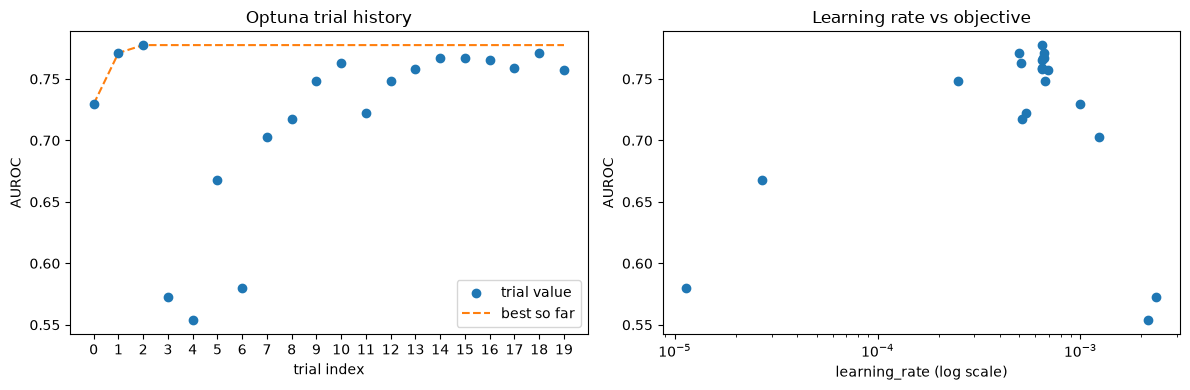

In [10]:
import matplotlib.pyplot as plt

completed = trials_df[trials_df["state"] == "COMPLETE"].copy()
completed = completed.reset_index(drop=True)

# Running best objective value over trial order
completed["best_so_far"] = completed["value"].cummax()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: objective value per trial
axes[0].scatter(completed.index, completed["value"], label="trial value", zorder=3)
axes[0].plot(completed.index, completed["best_so_far"],
             color="C1", linestyle="--", label="best so far")
axes[0].set_xlabel("trial index")
axes[0].set_xticks(completed.index)
axes[0].set_ylabel("AUROC")
axes[0].set_title("Optuna trial history")
axes[0].legend()

# Right: learning rate vs objective value
lr_col = next((c for c in completed.columns if "learning_rate" in c), None)
if lr_col:
    axes[1].scatter(completed[lr_col], completed["value"])
    axes[1].set_xscale("log")
    axes[1].set_xlabel("learning_rate (log scale)")
    axes[1].set_ylabel("AUROC")
    axes[1].set_title("Learning rate vs objective")

fig.tight_layout()
plt.show()

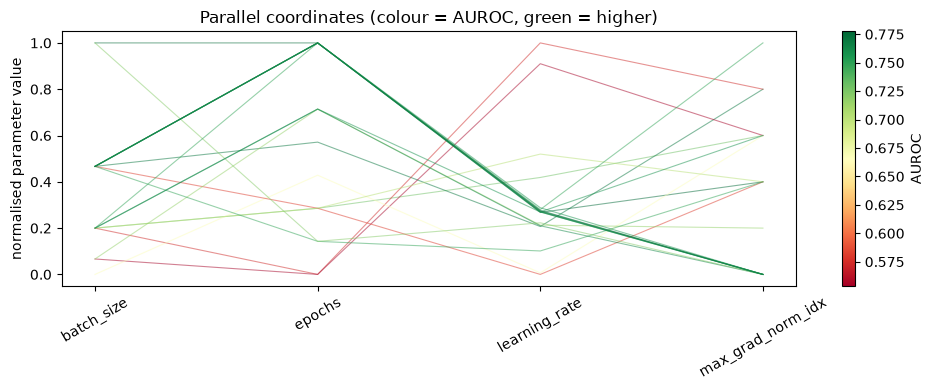

In [10]:
# Parallel coordinates plot for a quick multi-dimensional view
# (shows how hyperparameter combinations relate to the objective)
param_cols = [c for c in completed.columns if c.startswith("params_")]

if param_cols:
    from matplotlib.cm import RdYlGn
    from matplotlib.colors import Normalize

    norm = Normalize(vmin=completed["value"].min(), vmax=completed["value"].max())
    cmap = RdYlGn

    fig, ax = plt.subplots(figsize=(10, 4))

    # Normalise each parameter column to [0, 1] for display
    plot_df = completed[param_cols].copy()
    for col in param_cols:
        col_range = plot_df[col].max() - plot_df[col].min()
        if col_range > 0:
            plot_df[col] = (plot_df[col] - plot_df[col].min()) / col_range

    for _, row in completed.iterrows():
        color = cmap(norm(row["value"]))
        ax.plot(range(len(param_cols)), plot_df.loc[row.name, param_cols],
                color=color, alpha=0.5, linewidth=0.8)

    ax.set_xticks(range(len(param_cols)))
    ax.set_xticklabels([c.replace("params_", "") for c in param_cols], rotation=30)
    ax.set_ylabel("normalised parameter value")
    ax.set_title("Parallel coordinates (colour = AUROC, green = higher)")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label="AUROC")
    fig.tight_layout()
    plt.show()

## 7. Combining HPO with the epsilon sweep

A more rigorous epsilon sweep runs a separate HPO study per epsilon value, so each privacy budget gets its own fairly-tuned hyperparameters instead of reusing hand-picked values. 
The cell below is the shell equivalent of `sweep_epsilon_hpo.sh` from [tutorial_hpo.md](tutorial_hpo.md):

In [ ]:
%%bash
set -euo pipefail

EPSILONS=(1 3 8)
LOG_DIR="logs/tutorial_hpo_sweep"

for EPSILON in "${EPSILONS[@]}"; do
    EXPERIMENT_NAME="eyepacs_hpo_eps${EPSILON}"

    echo "=== HPO study for epsilon=${EPSILON} ==="

    dpdl optimize \
        --dataset-name bumbledeep/eyepacs \
        --dataset-label-field label_code \
        --model-name vit_tiny_patch16_224 \
        --metric-config conf/metrics/eyepacs.conf \
        --subset-size 0.05 \
        --target-epsilon "${EPSILON}" \
        --epochs 1 \
        --physical-batch-size 64 \
        --target-hypers learning_rate \
        --target-hypers batch_size \
        --target-hypers epochs \
        --target-hypers max_grad_norm \
        --optuna-config conf/optuna/eyepacs_hypers.conf \
        --optuna-manual-trials conf/optuna/eyepacs_trials.conf \
        --optuna-target-metric AUROC \
        --optuna-direction maximize \
        --n-trials 20 \
        --optuna-random-trials 5 \
        --device auto \
        --log-dir "${LOG_DIR}" \
        --experiment-name "${EXPERIMENT_NAME}" \
        --optuna-journal "${LOG_DIR}/${EXPERIMENT_NAME}.journal" \
        --overwrite-experiment
done

echo "=== Aggregating all studies ==="
python bin/aggregate-experiment-data-with-optuna-trials.py \
    "${LOG_DIR}" -o eyepacs_hpo_sweep_summary.json

### 7.1 Privacy/utility trade-off curve across HPO-tuned epsilons

Now we can compare not just *accuracy* across epsilon values but also
*which hyperparameters were actually best* at each privacy level.

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sweep_dir = Path("../logs/tutorial_hpo_sweep")
PATTERN = re.compile(r"eyepacs_hpo_eps(?P<epsilon>[\d.]+)$")

records = []
for exp_dir in sorted(sweep_dir.iterdir()):
    match = PATTERN.match(exp_dir.name)
    if not match or not (exp_dir / "final-metrics").exists():
        continue

    epsilon = float(match.group("epsilon"))
    final_metrics = json.loads((exp_dir / "final-metrics").read_text())
    best_params = json.loads((exp_dir / "best-params.json").read_text())
    final_epsilon = float((exp_dir / "final_epsilon").read_text().strip())

    records.append({
        "target_epsilon": epsilon,
        "actual_epsilon": final_epsilon,
        "test_auroc": final_metrics.get("test_auroc"),
        **{f"best_{k}": v for k, v in best_params.items()},
    })

sweep_df = pd.DataFrame(records).sort_values("target_epsilon").reset_index(drop=True)
sweep_df

,target_epsilon,actual_epsilon,test_auroc,best_learning_rate,best_epochs,best_total_steps,best_batch_size,best_sample_rate,best_noise_multiplier,best_max_grad_norm,best_target_epsilon,best_privacy,best_max_length
0,1.0,0.991634,0.765912,0.000500,5,None,512,None,None,5.0,1.0,True,None
1,3.0,2.999333,0.787932,0.000466,8,None,512,None,None,10.0,3.0,True,None
2,8.0,7.995198,0.796127,0.000474,8,None,512,None,None,10.0,8.0,True,None


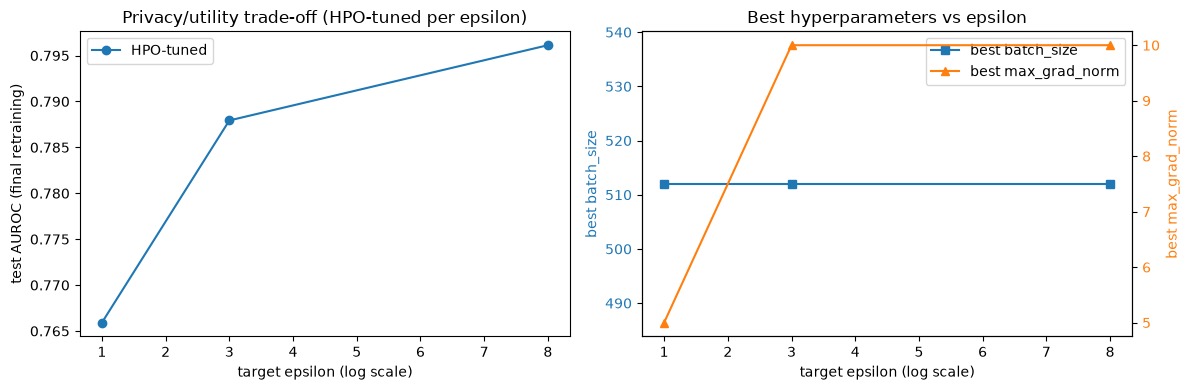

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: privacy/utility trade-off (one point per epsilon — single HPO run each)
axes[0].plot(
    sweep_df["target_epsilon"],
    sweep_df["test_auroc"],
    marker="o",
    label="HPO-tuned",
)
axes[0].set_xlabel("target epsilon (log scale)")
axes[0].set_ylabel("test AUROC (final retraining)")
axes[0].set_title("Privacy/utility trade-off (HPO-tuned per epsilon)")
axes[0].legend()

# Right: how the best batch size and max_grad_norm change with epsilon
# (it's common for tighter budgets to prefer larger batch sizes / fewer epochs)
if "best_batch_size" in sweep_df.columns:
    ax2 = axes[1]
    ax2b = ax2.twinx()

    ax2.plot(
        sweep_df["target_epsilon"],
        sweep_df["best_batch_size"],
        marker="s",
        color="C0",
        label="best batch_size",
    )
    if "best_max_grad_norm" in sweep_df.columns:
        ax2b.plot(
            sweep_df["target_epsilon"],
            sweep_df["best_max_grad_norm"],
            marker="^",
            color="C1",
            label="best max_grad_norm",
        )
        ax2b.set_ylabel("best max_grad_norm", color="C1")
        ax2b.tick_params(axis="y", labelcolor="C1")

    ax2.set_xlabel("target epsilon (log scale)")
    ax2.set_ylabel("best batch_size", color="C0")
    ax2.tick_params(axis="y", labelcolor="C0")
    ax2.set_title("Best hyperparameters vs epsilon")

    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2b.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2)

fig.tight_layout()
plt.show()

### Resuming an interrupted study

If a `dpdl optimize` run gets interrupted before finishing all `--n-trials`, rerun the exact same command with `--optuna-resume` added. 
DPDL will reload the existing study from `--optuna-journal` (matched by `--experiment-name`) and continue from where it left off. 

## 8. Next steps

- Widen `conf/optuna/eyepacs_hypers.conf`'s ranges and increase `--n-trials` for a real (non-tutorial) study
- Try a different sampler (`--optuna-sampler TPESampler` or `RandomSampler`) and compare `bin/report.py` output across studies with the same search space, to evaluate how much the sampler
  choice changes the outcome.
- Once you have a `best-params.json` for a given epsilon, plug those exact hyperparameters back into `dpdl train` (or `--optuna-manual-trials`) across several seeds to get a mean ± std accuracy estimate for your final reported number, the same way [tutorial.ipynb](tutorial.ipynb) does for hand-picked hyperparameters.